In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\Dell\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


# Project Phase 1 

In [ ]:
Understanding the Data

In [2]:
df = pd.read_csv(r"C:\Users\Dell\Downloads\ai4i_2020+predictive_maintenance\ai4i2020.csv")

df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [6]:
df.shape

(10000, 14)

In [7]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='str')

In [ ]:
| Column                    | Meaning                             | Type              |
| ------------------------- | ----------------------------------- | ----------------- |
| `UDI`                     | Unique row identifier               | ID                |
| `Product ID`              | Product/machine identifier          | ID                |
| `Type`                    | Product quality/type category       | Categorical       |
| `Air temperature [K]`     | Ambient air temperature             | Numerical         |
| `Process temperature [K]` | Process temperature                 | Numerical         |
| `Rotational speed [rpm]`  | Machine rotational speed            | Numerical         |
| `Torque [Nm]`             | Applied torque                      | Numerical         |
| `Tool wear [min]`         | Tool usage/wear time                | Numerical         |
| `Machine failure`         | Whether machine experienced failure | **Target**        |
| `TWF`                     | Tool Wear Failure                   | Failure indicator |
| `HDF`                     | Heat Dissipation Failure            | Failure indicator |
| `PWF`                     | Power Failure                       | Failure indicator |
| `OSF`                     | Overstrain Failure                  | Failure indicator |
| `RNF`                     | Random Failure                      | Failure indicator |


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

In [9]:
df.isnull().sum() > 0

UDI                        False
Product ID                 False
Type                       False
Air temperature [K]        False
Process temperature [K]    False
Rotational speed [rpm]     False
Torque [Nm]                False
Tool wear [min]            False
Machine failure            False
TWF                        False
HDF                        False
PWF                        False
OSF                        False
RNF                        False
dtype: bool

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [ ]:
# Check the target

In [12]:
df["Machine failure"].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

In [13]:
df["Machine failure"].value_counts(normalize=True) * 100

Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64

# Project Phase 2 

In [ ]:
Data Quality & Target Analysis

In [ ]:
# Check unique values

In [3]:
for col in df.columns:
    print(f"\n{col}")
    print(df[col].nunique())


UDI
10000

Product ID
10000

Type
3

Air temperature [K]
93

Process temperature [K]
82

Rotational speed [rpm]
941

Torque [Nm]
577

Tool wear [min]
246

Machine failure
2

TWF
2

HDF
2

PWF
2

OSF
2

RNF
2


In [ ]:
# Check the Type distribution

In [15]:
df["Type"].value_counts()

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

In [ ]:
Type L → lower failure rate
Type M → medium failure rate
Type H → higher failure rate

In [ ]:
# Check failure rate by machine/product type

In [4]:
pd.crosstab( df["Type"], df["Machine failure"], normalize="index") * 100

Machine failure,0,1
Type,,
H,97.906281,2.093719
L,96.083333,3.916667
M,97.230564,2.769436


In [ ]:
# Check failure counts by type

In [5]:
pd.crosstab(
    df["Type"],
    df["Machine failure"]
)

Machine failure,0,1
Type,,
H,982,21
L,5765,235
M,2914,83


In [ ]:
Failure rate by type
_____________________________________________

| Type | No Failure | Failure | Failure Rate |
| ---- | ---------: | ------: | -----------: |
| H    |        982 |      21 |    **2.09%** |
| L    |      5,765 |     235 |    **3.92%** |
| M    |      2,914 |      83 |    **2.77%** |


In [ ]:
# Understand the Numerical Variables

In [6]:
numeric_cols = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Air temperature [K],10000.0,300.00493,2.000259,295.3,298.3,300.1,301.5,304.5
Process temperature [K],10000.0,310.00556,1.483734,305.7,308.8,310.1,311.1,313.8
Rotational speed [rpm],10000.0,1538.77610,179.284096,1168.0,1423.0,1503.0,1612.0,2886.0
Torque [Nm],10000.0,39.98691,9.968934,3.8,33.2,40.1,46.8,76.6
Tool wear [min],10000.0,107.95100,63.654147,0.0,53.0,108.0,162.0,253.0


In [7]:
df.groupby("Machine failure")[numeric_cols].mean().T

Machine failure,0,1
Air temperature [K],299.973999,300.886431
Process temperature [K],309.995570,310.290265
Rotational speed [rpm],1540.260014,1496.486726
Torque [Nm],39.629655,50.168142
Tool wear [min],106.693717,143.781711


In [ ]:
 *************************First Observation******************************** 

             Failed machines have considerably higher averages:
             Torque and Tool wear than machines that didn't fail.

# Project Phase 3

In [ ]:
Visual EDA

In [ ]:
# How are the sensor values distributed for normal v/s failed machines?

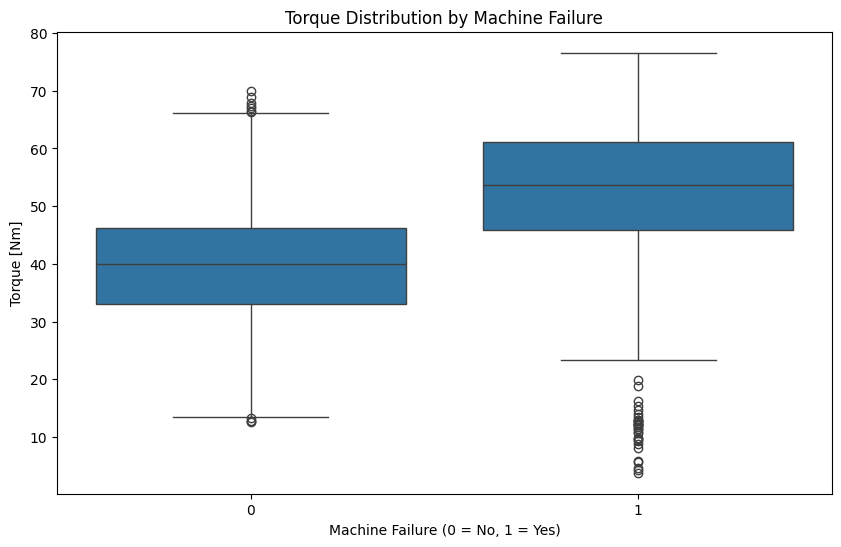

In [20]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Machine failure",
    y="Torque [Nm]"
)

plt.title("Torque Distribution by Machine Failure")
plt.xlabel("Machine Failure (0 = No, 1 = Yes)")
plt.ylabel("Torque [Nm]")

plt.show()

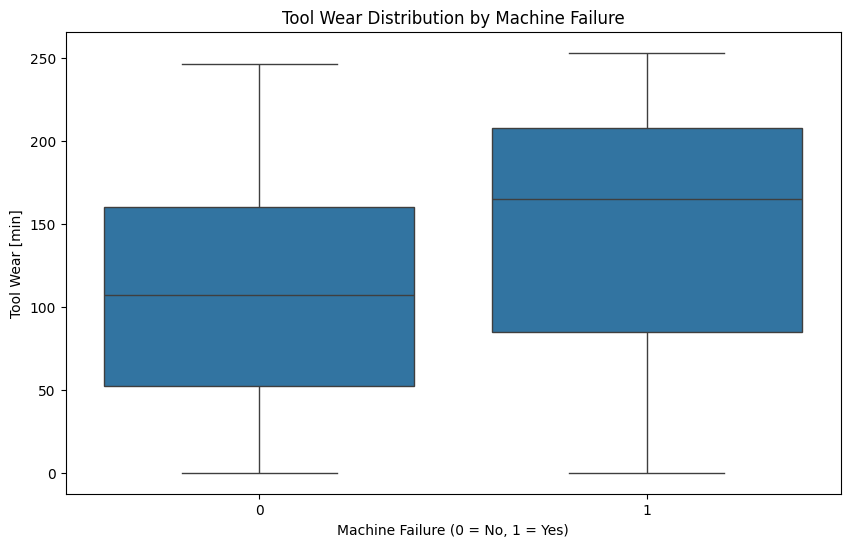

In [19]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Machine failure",
    y="Tool wear [min]"
)

plt.title("Tool Wear Distribution by Machine Failure")
plt.xlabel("Machine Failure (0 = No, 1 = Yes)")
plt.ylabel("Tool Wear [min]")

plt.show()

In [ ]:
One thing I like about this analysis

Failed machines tend to have higher torque, and failed machines tend to have higher tool wear.

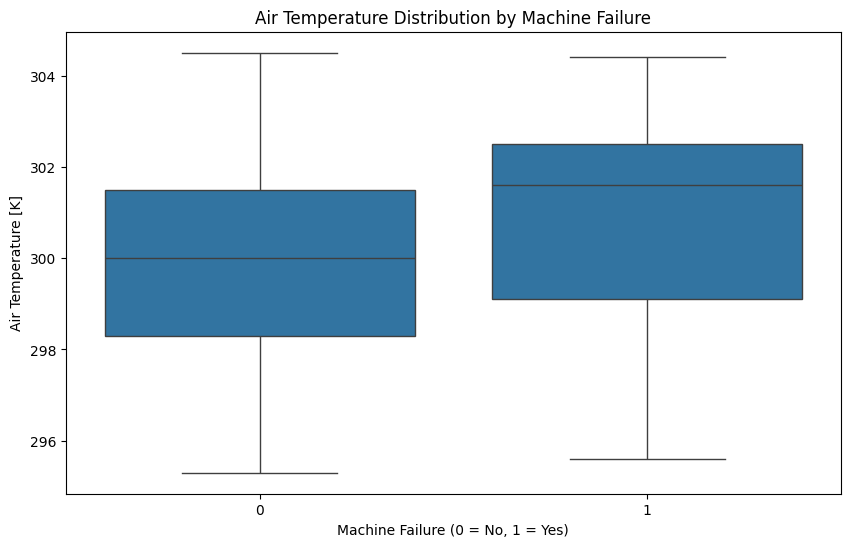

In [20]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Machine failure",
    y="Air temperature [K]"
)

plt.title("Air Temperature Distribution by Machine Failure")
plt.xlabel("Machine Failure (0 = No, 1 = Yes)")
plt.ylabel("Air Temperature [K]")

plt.show()

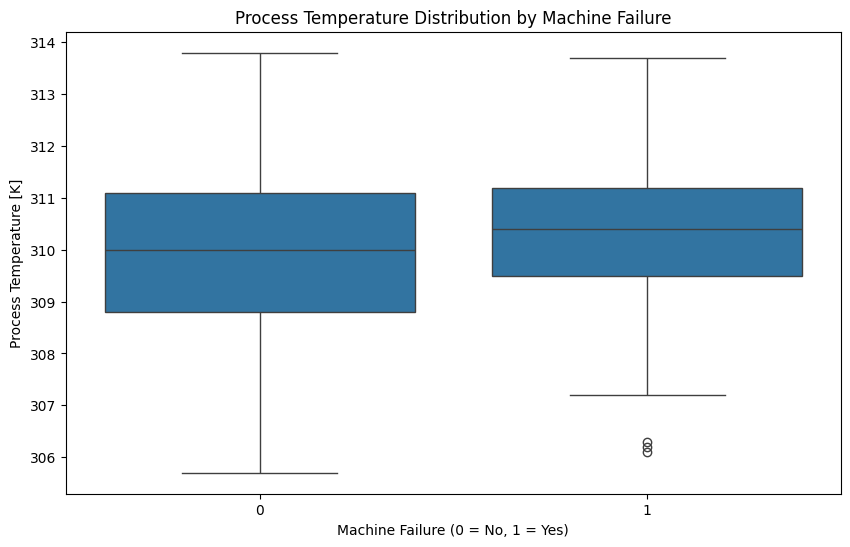

In [21]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Machine failure",
    y="Process temperature [K]"
)

plt.title("Process Temperature Distribution by Machine Failure")
plt.xlabel("Machine Failure (0 = No, 1 = Yes)")
plt.ylabel("Process Temperature [K]")

plt.show()

In [ ]:
| Variable                | Difference between groups | Initial observation      |
| ----------------------- | ------------------------- | ------------------------ |
| **Tool Wear**           | Large                     | 🔎 Strong signal         |
| **Torque**              | Large                     | 🔎 Strong signal         |
| **Air Temperature**     | Moderate                  | Potential signal         |
| **Process Temperature** | Small                     | Weaker individual signal |
| **RPM**                 | TBD                       | Need to investigate      |


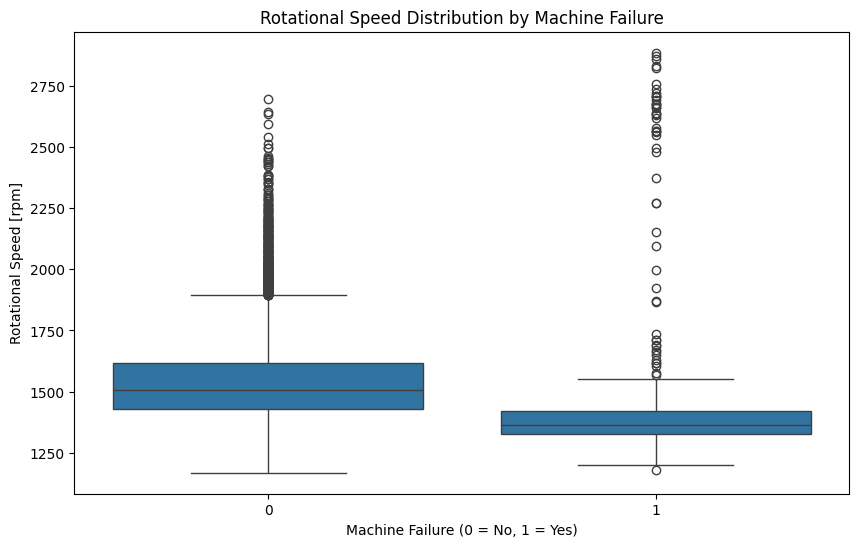

In [22]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Machine failure",
    y="Rotational speed [rpm]"
)

plt.title("Rotational Speed Distribution by Machine Failure")
plt.xlabel("Machine Failure (0 = No, 1 = Yes)")
plt.ylabel("Rotational Speed [rpm]")

plt.show()

In [ ]:
We now have a much better understanding of our variables:


| Variable            | Initial signal                             |
| ------------------- | ------------------------------------------ |
| Tool Wear           | Strong                                     |
| Torque              | Strong                                     |
| Air Temperature     | Moderate                                   |
| Process Temperature | Weak/moderate                              |
| RPM                 | Interesting nonlinear/complex relationship |


In [ ]:
# Correlation Analysis

In [8]:
corr = df[numeric_cols + ["Machine failure"]].corr()

corr

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
Air temperature [K],1.000000,0.876107,0.022670,-0.013778,0.013853,0.082556
Process temperature [K],0.876107,1.000000,0.019277,-0.014061,0.013488,0.035946
Rotational speed [rpm],0.022670,0.019277,1.000000,-0.875027,0.000223,-0.044188
Torque [Nm],-0.013778,-0.014061,-0.875027,1.000000,-0.003093,0.191321
Tool wear [min],0.013853,0.013488,0.000223,-0.003093,1.000000,0.105448
Machine failure,0.082556,0.035946,-0.044188,0.191321,0.105448,1.000000


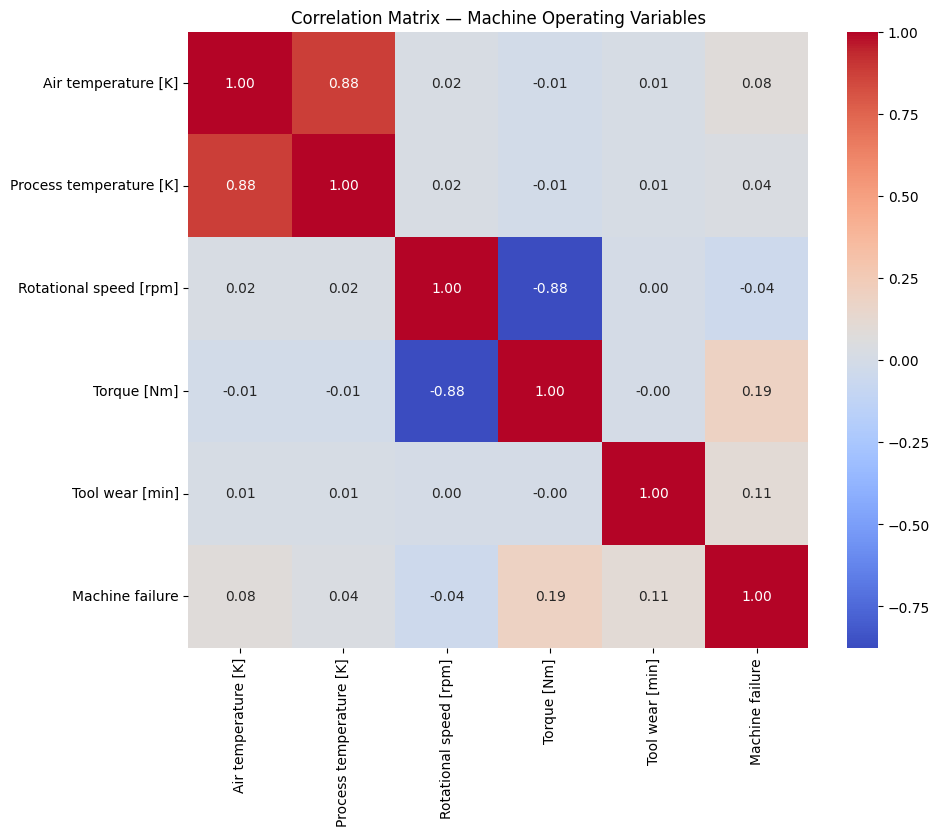

In [24]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix — Machine Operating Variables")
plt.show()

In [ ]:
# How does the observed failure rate change as torque increases

In [9]:
df["Torque_bin"] = pd.cut(
    df["Torque [Nm]"],
    bins=5
)

failure_by_torque = (
    df.groupby("Torque_bin", observed=True)["Machine failure"]
      .agg(["count", "sum", "mean"])
)

failure_by_torque["failure_rate_%"] = (
    failure_by_torque["mean"] * 100
)

failure_by_torque

,count,sum,mean,failure_rate_%
Torque_bin,,,,
"(3.727, 18.36]",150,32,0.213333,21.333333
"(18.36, 32.92]",2280,15,0.006579,0.657895
"(32.92, 47.48]",5294,51,0.009634,0.963355
"(47.48, 62.04]",2145,166,0.077389,7.738928
"(62.04, 76.6]",131,75,0.572519,57.251908


In [24]:
Interpreting Failure Rate by Torque

| Torque range | Machines | Failures | Failure rate |
| ------------ | -------: | -------: | -----------: |
| 3.73–18.36   |      150 |       32 |   **21.33%** |
| 18.36–32.92  |    2,280 |       15 |    **0.66%** |
| 32.92–47.48  |    5,294 |       51 |    **0.96%** |
| 47.48–62.04  |    2,145 |      166 |    **7.74%** |
| 62.04–76.60  |      131 |       75 |   **57.25%** |

In [ ]:
# How does failure rate change as tool wear increases?

In [10]:
df["Tool_wear_bin"] = pd.cut(
    df["Tool wear [min]"],
    bins=5
)

failure_by_tool_wear = (
    df.groupby("Tool_wear_bin", observed=True)["Machine failure"]
      .agg(["count", "sum", "mean"])
)

failure_by_tool_wear["failure_rate_%"] = (
    failure_by_tool_wear["mean"] * 100
)

failure_by_tool_wear

,count,sum,mean,failure_rate_%
Tool_wear_bin,,,,
"(-0.253, 50.6]",2396,52,0.021703,2.170284
"(50.6, 101.2]",2319,56,0.024148,2.414834
"(101.2, 151.8]",2285,48,0.021007,2.100656
"(151.8, 202.4]",2328,70,0.030069,3.006873
"(202.4, 253.0]",672,113,0.168155,16.815476


In [ ]:
# Interpreting Tool Wear

| Tool wear range | Machines | Failures | Failure rate |
| --------------- | -------: | -------: | -----------: |
| ~0–50 min       |    2,396 |       52 |    **2.17%** |
| 50–101 min      |    2,319 |       56 |    **2.41%** |
| 101–152 min     |    2,285 |       48 |    **2.10%** |
| 152–202 min     |    2,328 |       70 |    **3.01%** |
| 202–253 min     |      672 |      113 |   **16.82%** |


In [ ]:
Compare Tool Wear and Torque

Torque
18–47 Nm → ~0.7–1.0%
47–62 Nm → 7.7%
62+ Nm   → 57.3%

Tool Wear
0–202 min  → ~2–3%
202+ min   → 16.8%

# Project Phase 4

In [ ]:
# Failure Mode Analysis

In [ ]:
# Count each failure mode

In [11]:
failure_modes = ["TWF", "HDF", "PWF", "OSF", "RNF"]

df[failure_modes].sum().sort_values(ascending=False)

HDF    115
OSF     98
PWF     95
TWF     46
RNF     19
dtype: int64

In [ ]:
# Check failure-mode overlap

In [12]:
df["num_failure_modes"] = df[failure_modes].sum(axis=1)

df["num_failure_modes"].value_counts().sort_index()

num_failure_modes
0    9652
1     324
2      23
3       1
Name: count, dtype: int64

In [ ]:
324    machines have exactly one recorded failure mode.
23     machines have two failure-mode indicators.
1      machine has three.
9,652  machines have none.

In [13]:
# Optional 

df.drop(
    columns=["Torque_bin", "Tool_wear_bin", "num_failure_modes"],
    inplace=True
)

In [ ]:
# Let's see the failure modes visually

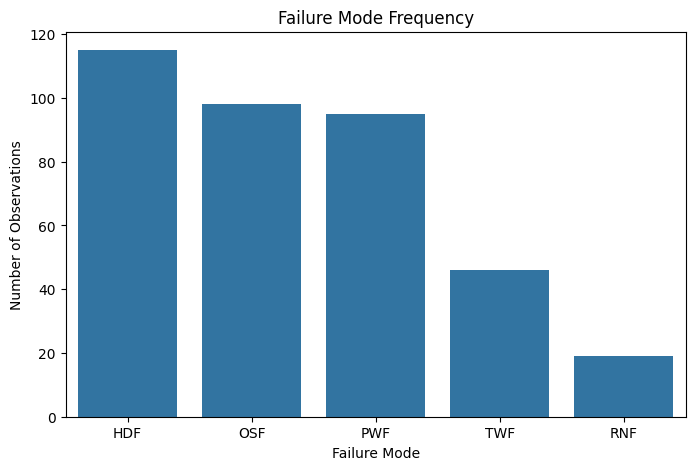

In [29]:
failure_counts = df[failure_modes].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=failure_counts.index,
    y=failure_counts.values
)

plt.title("Failure Mode Frequency")
plt.xlabel("Failure Mode")
plt.ylabel("Number of Observations")

plt.show()

In [ ]:
What we can say from this chart:

1) HDF (Heat Dissipation Failure): 115 — most frequent
2) OSF (Overstrain Failure): 98
3) PWF (Power Failure): 95
4) TWF (Tool Wear Failure): 46
5) RNF (Random Failure): 19 — least frequent

In [ ]:
# Connect machine conditions to failure modes

In [ ]:
1) HDF — Heat Dissipation Failure.

In [14]:
df.groupby("HDF")[numeric_cols].mean().T

HDF,0,1
Air temperature [K],299.975195,302.560870
Process temperature [K],309.996449,310.788696
Rotational speed [rpm],1541.120486,1337.260870
Torque [Nm],39.833576,53.166957
Tool wear [min],107.959838,107.191304


In [ ]:
2) OSF - Overstrain Failure

In [15]:
df.groupby("OSF")[numeric_cols].mean().T

OSF,0,1
Air temperature [K],300.004534,300.044898
Process temperature [K],310.004888,310.073469
Rotational speed [rpm],1540.641184,1350.326531
Torque [Nm],39.804969,58.370408
Tool wear [min],106.963846,207.693878


In [ ]:
3) PWF - Power Failure

In [16]:
df.groupby("PWF")[numeric_cols].mean().T

PWF,0,1
Air temperature [K],300.004250,300.075789
Process temperature [K],310.006047,309.954737
Rotational speed [rpm],1536.616254,1763.968421
Torque [Nm],39.905119,48.514737
Tool wear [min],108.009187,101.884211


In [ ]:
4) TWF - Tool Wear Failure

In [17]:
df.groupby("TWF")[numeric_cols].mean().T

TWF,0,1
Air temperature [K],300.003576,300.297826
Process temperature [K],310.004822,310.165217
Rotational speed [rpm],1538.649488,1566.173913
Torque [Nm],39.996845,37.836957
Tool wear [min],107.449970,216.369565


In [ ]:
5) RNF - Random Failure

In [18]:
df.groupby("RNF")[numeric_cols].mean().T

RNF,0,1
Air temperature [K],300.003386,300.815789
Process temperature [K],310.004118,310.763158
Rotational speed [rpm],1538.878469,1485.000000
Torque [Nm],39.979892,43.673684
Tool wear [min],107.919547,124.473684


In [ ]:
# Overall findings

In [ ]:
HDF — Heat Dissipation Failure
Observed pattern:

Higher air temperature
Slightly higher process temperature
Lower RPM
Higher torque
Similar tool wear

In [ ]:
OSF — Overstrain Failure
Strongest patterns:

Much higher torque
Much higher tool wear
Lower RPM

In [ ]:
PWF — Power Failure
Observed pattern:

Higher RPM
Higher torque
Similar temperatures
Similar/lower tool wear

In [ ]:
TWF — Tool Wear Failure
Strongest pattern by far:

Very high tool wear

In [ ]:
RNF — Random Failure

With only 19 observations, we can not draw strong conclusions.

In [ ]:
# Project Lineup so far

In [ ]:
Machine Sensors
       ↓
Data Quality
       ↓
Failure Imbalance
       ↓
Operating Conditions
       ↓
Failure-rate analysis
       ↓
Failure-mode analysis
       ↓
Engineering insights

# Project Phase 4

In [ ]:
# Prepare for Machine Learning

In [19]:
features = ["Type", "Air temperature [K]", "Process temperature [K]", "Rotational speed [rpm]", "Torque [Nm]", "Tool wear [min]" ]

target = "Machine failure"

X = df[features]
y = df[target]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Features:
['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

Target:
Machine failure

X shape: (10000, 6)
y shape: (10000,)


In [ ]:
# Train/Test Split

In [20]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.20, stratify=y, random_state=42)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training set: (8000, 6)
Test set: (2000, 6)

Training target distribution:
Machine failure
0    96.6125
1     3.3875
Name: proportion, dtype: float64

Test target distribution:
Machine failure
0    96.6
1     3.4
Name: proportion, dtype: float64


In [ ]:
# Handle the categorical feature

In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = ["Type"]

preprocessor = ColumnTransformer(
    transformers=[
        ("ABC", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ],
    remainder="passthrough"
)

In [ ]:
# Apply the preprocessing

In [22]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("X_train_processed shape:", X_train_processed.shape)
print("X_test_processed shape:", X_test_processed.shape)

X_train_processed shape: (8000, 8)
X_test_processed shape: (2000, 8)


In [23]:
# Build our first baseline model using LogisticRegression

In [24]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_processed, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [25]:
y_pred = model.predict(X_test_processed)

print("Number of predictions:", len(y_pred))

Number of predictions: 2000


In [26]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix( y_test, y_pred))
print(classification_report(y_test, y_pred))

[[1927    5]
 [  58   10]]
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1932
           1       0.67      0.15      0.24        68

    accuracy                           0.97      2000
   macro avg       0.82      0.57      0.61      2000
weighted avg       0.96      0.97      0.96      2000



In [27]:
y_prob = model.predict_proba(X_test_processed)[:, 1]

print("Number of probabilities:", len(y_prob))
print("First 10 probabilities:")
print(y_prob[:10])

Number of probabilities: 2000
First 10 probabilities:
[6.33437317e-01 2.33830386e-02 4.53217308e-02 4.53224981e-04
 1.91877771e-01 3.98560246e-02 9.68339677e-02 6.43291117e-03
 1.10533748e-03 8.57875839e-02]


In [28]:
from sklearn.metrics import roc_auc_score, average_precision_score

roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC : {pr_auc:.4f}")

ROC-AUC: 0.8995
PR-AUC : 0.4335


In [ ]:
An ROC-AUC of 0.8995 indicates that the model can fairly well rank failure cases above non-failure cases across thresholds.

PR-AUC of 0.4335 is also meaningful because the baseline failure prevalence is only 3.4%. It shows that the model is identifying useful signal 
in the minority class, rather than simply benefiting from the large number of normal machines.

In [ ]:
# Build Model using Random Forest

In [29]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced",n_jobs=-1)
rf_model.fit(X_train_processed, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=300, n_jobs=-1,
                       random_state=42)

In [30]:
rf_pred = rf_model.predict(X_test_processed)

rf_prob = rf_model.predict_proba(X_test_processed)[:, 1]

print("Number of predictions:", len(rf_pred))
print("Number of probabilities:", len(rf_prob))

Number of predictions: 2000
Number of probabilities: 2000


In [31]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix( y_test, rf_pred))
print(classification_report(y_test, rf_pred))

[[1929    3]
 [  37   31]]
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1932
           1       0.91      0.46      0.61        68

    accuracy                           0.98      2000
   macro avg       0.95      0.73      0.80      2000
weighted avg       0.98      0.98      0.98      2000



In [32]:
rf_roc_auc = roc_auc_score(y_test, rf_prob)
rf_pr_auc = average_precision_score(y_test, rf_prob)

print(f"Random Forest ROC-AUC: {rf_roc_auc:.4f}")
print(f"Random Forest PR-AUC : {rf_pr_auc:.4f}")

Random Forest ROC-AUC: 0.9585
Random Forest PR-AUC : 0.7745


In [33]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test,rf_prob)

print("Number of thresholds:", len(thresholds))
print("Precision values:", len(precision))
print("Recall values:", len(recall))

Number of thresholds: 124
Precision values: 125
Recall values: 125


In [ ]:
# Compare practical thresholds

In [34]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds_to_check = [0.10, 0.20, 0.30, 0.40, 0.50]

for threshold in thresholds_to_check:
    y_threshold_pred = (rf_prob >= threshold).astype(int)

    precision_value = precision_score(y_test,y_threshold_pred,zero_division=0)
    recall_value = recall_score(y_test, y_threshold_pred, zero_division=0)
    f1_value = f1_score(y_test, y_threshold_pred, zero_division=0)

    print(f"Threshold: {threshold:.2f} | "
          f"Precision: {precision_value:.2f} | "
          f"Recall: {recall_value:.2f} | "
          f"F1: {f1_value:.2f}" )

Threshold: 0.10 | Precision: 0.39 | Recall: 0.87 | F1: 0.54
Threshold: 0.20 | Precision: 0.59 | Recall: 0.79 | F1: 0.68
Threshold: 0.30 | Precision: 0.75 | Recall: 0.71 | F1: 0.73
Threshold: 0.40 | Precision: 0.86 | Recall: 0.62 | F1: 0.72
Threshold: 0.50 | Precision: 0.91 | Recall: 0.47 | F1: 0.62


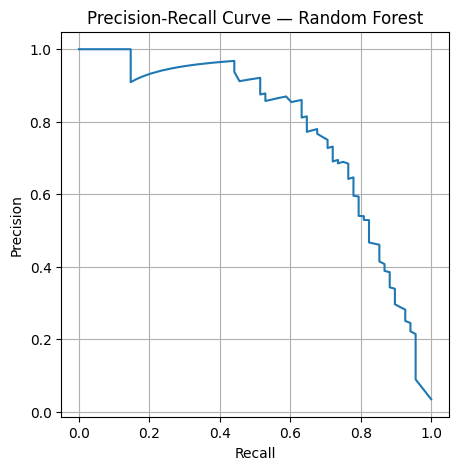

In [50]:
plt.figure(figsize=(5, 5))
plt.plot(recall,precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Random Forest")
plt.grid(True)

plt.show()

In [35]:
import numpy as np

f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)

best_index = np.argmax(f1_scores)

best_threshold = thresholds[best_index]
best_f1 = f1_scores[best_index]
best_precision = precision[best_index]
best_recall = recall[best_index]

print(f"Best threshold: {best_threshold:.4f}")
print(f"Best F1       : {best_f1:.4f}")
print(f"Precision     : {best_precision:.4f}")
print(f"Recall        : {best_recall:.4f}")

Best threshold: 0.3900
Best F1       : 0.7288
Precision     : 0.8600
Recall        : 0.6324


In [ ]:
# Build Model using XGBoost model

In [36]:
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

print("Normal machines:", negative_count)
print("Failure machines:", positive_count)
print("Scale pos weight:", scale_pos_weight)

Normal machines: 7729
Failure machines: 271
Scale pos weight: 28.52029520295203


In [37]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, scale_pos_weight=scale_pos_weight,
objective="binary:logistic",eval_metric="logloss", random_state=42, n_jobs=-1)

xgb_model.fit(X_train_processed, y_train)
print("XGBoost trained successfully.")

XGBoost trained successfully.


In [38]:
xgb_pred = xgb_model.predict(X_test_processed)
xgb_prob = xgb_model.predict_proba(X_test_processed)[:, 1]
print("Number of predictions:", len(xgb_pred))
print("Number of probabilities:", len(xgb_prob))

Number of predictions: 2000
Number of probabilities: 2000


In [39]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, xgb_pred))
print(classification_report(y_test, xgb_pred))

[[1900   32]
 [  14   54]]
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1932
           1       0.63      0.79      0.70        68

    accuracy                           0.98      2000
   macro avg       0.81      0.89      0.84      2000
weighted avg       0.98      0.98      0.98      2000



In [ ]:
XGBoost detects 54 of 68 failures, whereas Random Forest detected 31 of 68 at the default threshold.

In [40]:
xgb_roc_auc = roc_auc_score(y_test, xgb_prob)
xgb_pr_auc = average_precision_score(y_test, xgb_prob)

print(f"XGBoost ROC-AUC: {xgb_roc_auc:.4f}")
print(f"XGBoost PR-AUC : {xgb_pr_auc:.4f}")

XGBoost ROC-AUC: 0.9740
XGBoost PR-AUC : 0.8241


# Project Phase 5

In [ ]:
# Model comparison

In [ ]:
| Metric            | Logistic Regression | Random Forest |    XGBoost |
| ----------------- | ------------------: | ------------: | ---------: |
| Accuracy          |                0.97 |          0.98 |       0.98 |
| Failure Precision |                0.67 |          0.91 |       0.63 |
| Failure Recall    |                0.15 |          0.46 |       0.79 |
| Failure F1        |                0.24 |          0.61 |       0.70 |
| ROC-AUC           |              0.8995 |        0.9585 |      0.974 |
| PR-AUC            |              0.4335 |        0.7745 |      0.824 |

In [ ]:
# XGBoost threshold analysis

In [41]:
thresholds_to_check = [0.10, 0.20, 0.30, 0.40, 0.50]

for threshold in thresholds_to_check:
    y_threshold_pred = (xgb_prob >= threshold).astype(int)

    precision_value = precision_score(
        y_test,
        y_threshold_pred,
        zero_division=0
    )

    recall_value = recall_score(
        y_test,
        y_threshold_pred,
        zero_division=0
    )

    f1_value = f1_score(
        y_test,
        y_threshold_pred,
        zero_division=0
    )

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision_value:.2f} | "
        f"Recall: {recall_value:.2f} | "
        f"F1: {f1_value:.2f}"
    )

Threshold: 0.10 | Precision: 0.35 | Recall: 0.88 | F1: 0.50
Threshold: 0.20 | Precision: 0.45 | Recall: 0.85 | F1: 0.59
Threshold: 0.30 | Precision: 0.51 | Recall: 0.84 | F1: 0.64
Threshold: 0.40 | Precision: 0.56 | Recall: 0.81 | F1: 0.66
Threshold: 0.50 | Precision: 0.63 | Recall: 0.79 | F1: 0.70


In [ ]:
# Find XGBoost's best F1 threshold

In [42]:
xgb_precision_curve, xgb_recall_curve, xgb_thresholds = precision_recall_curve(
    y_test,
    xgb_prob
)

xgb_f1_scores = (
    2 * xgb_precision_curve * xgb_recall_curve
    / (xgb_precision_curve + xgb_recall_curve + 1e-10)
)

best_index = np.argmax(xgb_f1_scores)

best_xgb_threshold = xgb_thresholds[best_index]
best_xgb_f1 = xgb_f1_scores[best_index]
best_xgb_precision = xgb_precision_curve[best_index]
best_xgb_recall = xgb_recall_curve[best_index]

print(f"Best threshold: {best_xgb_threshold:.4f}")
print(f"Best F1       : {best_xgb_f1:.4f}")
print(f"Precision     : {best_xgb_precision:.4f}")
print(f"Recall        : {best_xgb_recall:.4f}")

Best threshold: 0.8756
Best F1       : 0.7966
Precision     : 0.9400
Recall        : 0.6912


In [ ]:
# Create a validation set

In [43]:
X_train_model, X_val, y_train_model, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    stratify=y_train,
    random_state=42
)

print("Model training set:", X_train_model.shape)
print("Validation set:", X_val.shape)

print("\nModel training failure rate:")
print(y_train_model.mean() * 100)

print("\nValidation failure rate:")
print(y_val.mean() * 100)

Model training set: (6400, 6)
Validation set: (1600, 6)

Model training failure rate:
3.390625

Validation failure rate:
3.375


In [ ]:
# Refit preprocessing on the model-training set

In [44]:
preprocessor_final = ColumnTransformer(
    transformers=[
        ("ABC", OneHotEncoder(handle_unknown="ignore"), ["Type"])
    ],
    remainder="passthrough"
)

X_train_model_processed = preprocessor_final.fit_transform(X_train_model)
X_val_processed = preprocessor_final.transform(X_val)
X_test_final_processed = preprocessor_final.transform(X_test)

print("Training:", X_train_model_processed.shape)
print("Validation:", X_val_processed.shape)
print("Test:", X_test_final_processed.shape)

Training: (6400, 8)
Validation: (1600, 8)
Test: (2000, 8)


In [93]:
# Retrain XGBoost on the clean training set

In [45]:
negative_count = (y_train_model == 0).sum()
positive_count = (y_train_model == 1).sum()

scale_pos_weight_final = negative_count / positive_count

print("Normal machines:", negative_count)
print("Failure machines:", positive_count)
print("Scale pos weight:", scale_pos_weight_final)

Normal machines: 6183
Failure machines: 217
Scale pos weight: 28.493087557603687


In [46]:
xgb_final = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight_final,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_final.fit(
    X_train_model_processed,
    y_train_model
)

print("Clean XGBoost model trained successfully.")

Clean XGBoost model trained successfully.


In [96]:
# Generate validation probabilities

In [47]:
xgb_val_prob = xgb_final.predict_proba(X_val_processed)[:, 1]

print("Validation probabilities:", len(xgb_val_prob))
print("First 10 probabilities:")
print(xgb_val_prob[:10])

Validation probabilities: 1600
First 10 probabilities:
[7.7307137e-04 4.2618815e-02 6.4569415e-04 3.8803965e-02 1.8107540e-03
 9.6263295e-01 4.7464535e-02 1.4101644e-03 6.2438071e-04 1.2102241e-03]


In [98]:
# Find the threshold using validation data

In [48]:
from sklearn.metrics import precision_recall_curve
import numpy as np

val_precision, val_recall, val_thresholds = precision_recall_curve(
    y_val,
    xgb_val_prob
)

val_f1_scores = (
    2 * val_precision * val_recall
    / (val_precision + val_recall + 1e-10)
)

best_val_index = np.argmax(val_f1_scores)

best_val_threshold = val_thresholds[best_val_index]
best_val_f1 = val_f1_scores[best_val_index]
best_val_precision = val_precision[best_val_index]
best_val_recall = val_recall[best_val_index]

print(f"Selected threshold: {best_val_threshold:.4f}")
print(f"Validation F1      : {best_val_f1:.4f}")
print(f"Validation precision: {best_val_precision:.4f}")
print(f"Validation recall   : {best_val_recall:.4f}")

Selected threshold: 0.6761
Validation F1      : 0.7115
Validation precision: 0.7400
Validation recall   : 0.6852


In [100]:
# Final test evaluation

In [49]:
xgb_test_prob = xgb_final.predict_proba( X_test_final_processed)[:, 1]
print("Final test probabilities:", len(xgb_test_prob))

Final test probabilities: 2000


In [50]:
xgb_test_pred = (xgb_test_prob >= best_val_threshold).astype(int)
print("Final test predictions:", len(xgb_test_pred))

Final test predictions: 2000


In [51]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test,  xgb_test_pred))
print(classification_report(y_test,  xgb_test_pred))

[[1916   16]
 [  17   51]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.76      0.75      0.76        68

    accuracy                           0.98      2000
   macro avg       0.88      0.87      0.87      2000
weighted avg       0.98      0.98      0.98      2000



In [52]:
final_roc_auc = roc_auc_score(y_test, xgb_test_prob)
final_pr_auc = average_precision_score(y_test, xgb_test_prob)

print(f"Final ROC-AUC: {final_roc_auc:.4f}")
print(f"Final PR-AUC : {final_pr_auc:.4f}")

Final ROC-AUC: 0.9700
Final PR-AUC : 0.8131


In [106]:
| Model               |    ROC-AUC |     PR-AUC | Failure Precision | Failure Recall | Failure F1 |
| ------------------- | ---------: | ---------: | ----------------: | -------------: | ---------: |
| Logistic Regression |     0.8995 |     0.4335 |              0.67 |           0.15 |       0.24 |
| Random Forest       |     0.9585 |     0.7745 |              0.91 |           0.46 |       0.61 |
| **XGBoost — final** | **0.9700** | **0.8131** |          **0.76** |       **0.75** |   **0.76** |

In [ ]:
# XGBoost Feature Importance

In [53]:
feature_names = preprocessor_final.get_feature_names_out()

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgb_final.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
6,remainder__Torque [Nm],0.245882
5,remainder__Rotational speed [rpm],0.245105
7,remainder__Tool wear [min],0.199972
3,remainder__Air temperature [K],0.102362
4,remainder__Process temperature [K],0.066904
1,ABC__Type_L,0.051607
2,ABC__Type_M,0.051185
0,ABC__Type_H,0.036982


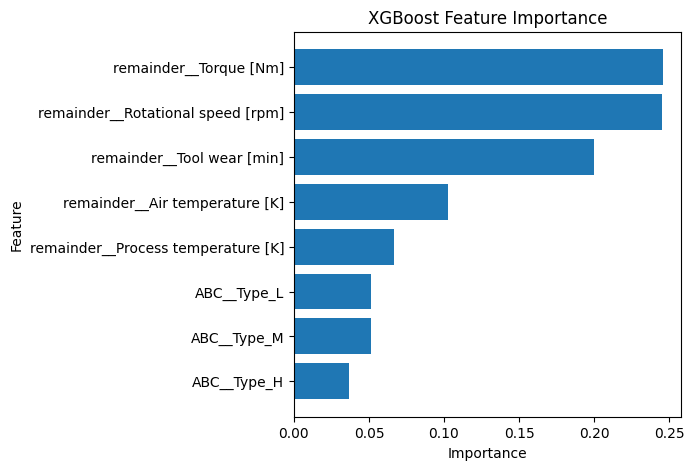

In [70]:
plt.figure(figsize=(5, 5))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")

plt.gca().invert_yaxis()
plt.show()

In [ ]:
# Create the SHAP explainer

In [54]:
import shap
explainer = shap.TreeExplainer(xgb_final)
print("SHAP explainer created successfully.")

SHAP explainer created successfully.


In [ ]:
# Calculate SHAP values

In [55]:
# Use a sample of the test set for SHAP analysis
X_test_shap = X_test_final_processed[:500]

# Calculate SHAP values
shap_values = explainer(X_test_shap)

print("SHAP values calculated successfully.")
print("Shape:", shap_values.values.shape)

SHAP values calculated successfully.
Shape: (500, 8)


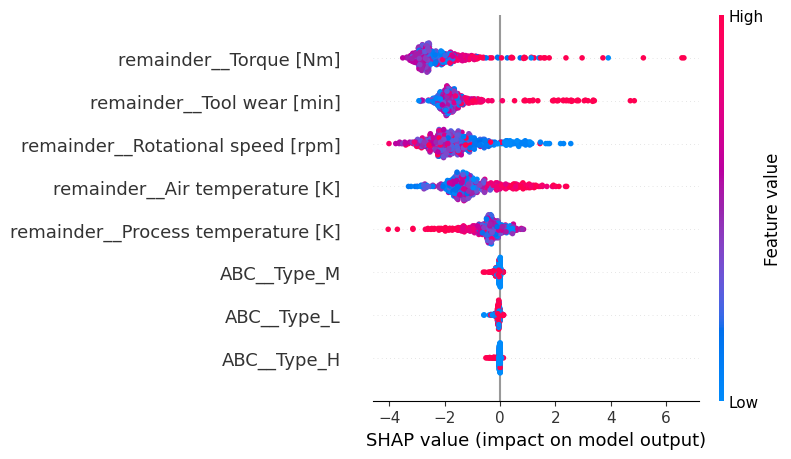

In [76]:
shap.summary_plot(
    shap_values.values,
    X_test_shap,
    feature_names=feature_names
)

In [ ]:
SHAP analysis showed that torque, tool wear, and rotational speed were the main contributors to the XGBoost models failure predictions. 
Higher torque and tool wear generally increased predicted failure risk, while lower rotational speed tended to increase the models failure prediction.
Machine type had comparatively little influence.

In [ ]:
# Create a simpler global importance plot

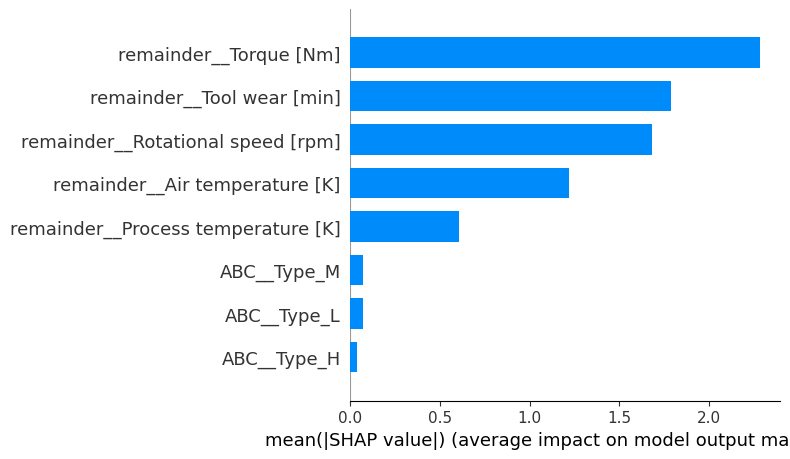

In [74]:
shap.summary_plot(
    shap_values.values,
    X_test_shap,
    feature_names=feature_names,
    plot_type="bar"
)

In [56]:
clean_feature_names = [
    "Type_H",
    "Type_L",
    "Type_M",
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

print(clean_feature_names)

['Type_H', 'Type_L', 'Type_M', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']


In [ ]:
# Update the SHAP summary plot

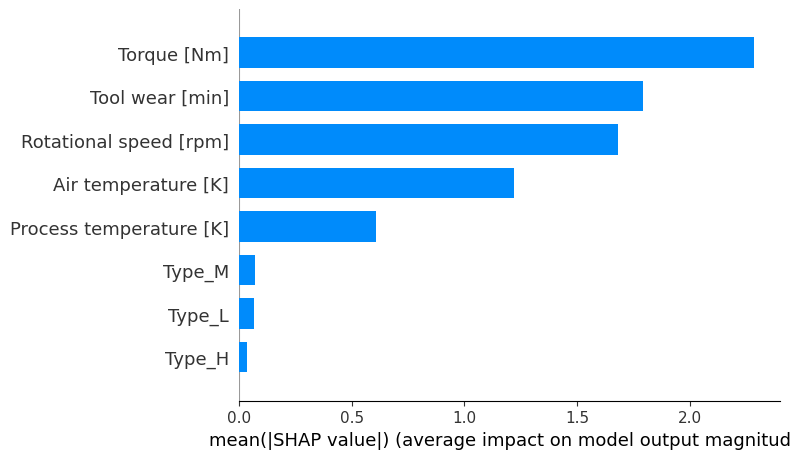

In [77]:
shap.summary_plot(
    shap_values.values,
    X_test_shap,
    feature_names=clean_feature_names,
    plot_type="bar"
)

In [57]:
# Find test observations predicted as failure
failure_indices = np.where(xgb_test_pred == 1)[0]

# Select the first predicted failure
sample_idx = failure_indices[0]

print("Test observation index:", sample_idx)
print("Predicted probability:", round(xgb_test_prob[sample_idx], 4))
print("Predicted class:", xgb_test_pred[sample_idx])
print("Actual class:", y_test.iloc[sample_idx])

Test observation index: 21
Predicted probability: 0.9806
Predicted class: 1
Actual class: 1


In [58]:
# Get the original feature values for this test observation
sample_features = X_test.iloc[sample_idx]

print(sample_features)

Type                           L
Air temperature [K]        298.9
Process temperature [K]    310.2
Rotational speed [rpm]      2737
Torque [Nm]                  8.8
Tool wear [min]              142
Name: 1391, dtype: object


In [ ]:
# Calculate individual SHAP contributions

In [59]:
# Get SHAP contributions for this specific machine
sample_shap = shap_values.values[sample_idx]

# Create a table of feature contributions
sample_explanation = pd.DataFrame({
    "Feature": clean_feature_names,
    "SHAP value": sample_shap
}).sort_values(
    by="SHAP value",
    key=abs,
    ascending=False
)

print(sample_explanation)

                   Feature  SHAP value
6              Torque [Nm]    3.906406
5   Rotational speed [rpm]    1.440309
7          Tool wear [min]   -1.038907
3      Air temperature [K]   -0.981619
4  Process temperature [K]   -0.177365
1                   Type_L   -0.059717
0                   Type_H    0.049200
2                   Type_M   -0.031493


In [ ]:
| Feature                    | SHAP impact | Interpretation                  |
| -------------------------- | ----------: | ------------------------------- |
| **Torque [Nm]**            |   **+3.91** | Strongly pushed toward failure  |
| **Rotational speed [rpm]** |   **+1.44** | Pushed toward failure           |
| Tool wear [min]            |       −1.04 | Pushed away from failure        |
| Air temperature [K]        |       −0.98 | Pushed away from failure        |
| Process temperature [K]    |       −0.18 | Slightly pushed away            |
| Type_H                     |       +0.05 | Very small failure contribution |
| Type_L                     |       −0.06 | Very small contribution         |
| Type_M                     |       −0.03 | Very small contribution         |


In [ ]:
# Create the individual SHAP waterfall plot

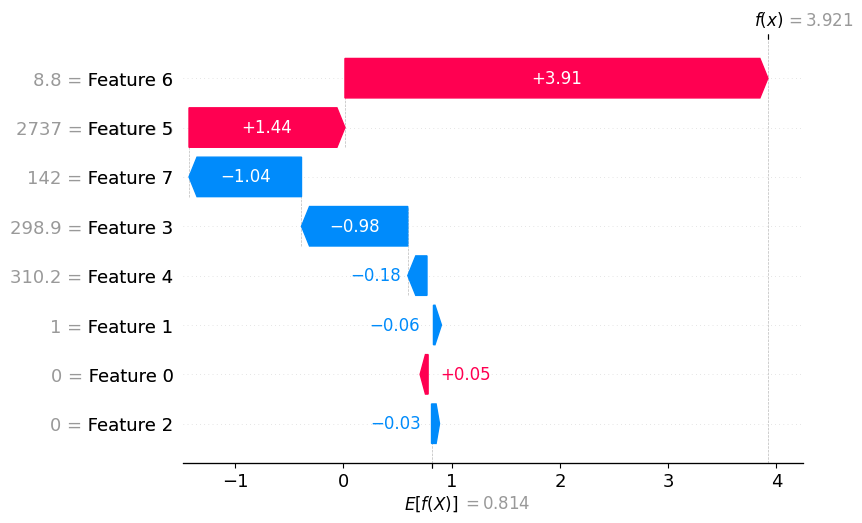

In [81]:
shap.plots.waterfall(
    shap_values[sample_idx],
    max_display=8
)

In [ ]:
# Create a SHAP explanation for a correctly predicted normal machine

In [60]:
# Find test observations predicted as normal and actually normal
normal_indices = np.where(
    (xgb_test_pred == 0) & (y_test.values == 0)
)[0]

# Select the first correctly predicted normal observation
normal_idx = normal_indices[0]

print("Test observation index:", normal_idx)
print("Predicted probability:", round(xgb_test_prob[normal_idx], 4))
print("Predicted class:", xgb_test_pred[normal_idx])
print("Actual class:", y_test.iloc[normal_idx])

Test observation index: 0
Predicted probability: 0.5452
Predicted class: 0
Actual class: 0


In [61]:
normal_features = X_test.iloc[normal_idx]

print(normal_features)

Type                           L
Air temperature [K]        300.5
Process temperature [K]    309.8
Rotational speed [rpm]      1345
Torque [Nm]                 62.7
Tool wear [min]              153
Name: 2997, dtype: object


In [ ]:
# Calculate SHAP contributions for this normal prediction

In [62]:
normal_shap = shap_values.values[normal_idx]

normal_explanation = pd.DataFrame({
    "Feature": clean_feature_names,
    "SHAP value": normal_shap
}).sort_values(
    by="SHAP value",
    key=abs,
    ascending=False
)

print(normal_explanation)

                   Feature  SHAP value
6              Torque [Nm]    2.378892
7          Tool wear [min]   -2.013964
3      Air temperature [K]   -1.442932
5   Rotational speed [rpm]    0.357112
4  Process temperature [K]    0.138478
1                   Type_L   -0.038884
0                   Type_H   -0.008401
2                   Type_M   -0.003004


In [ ]:
What the model saw:

1) Torque: +2.38 → pushed toward failure
2) Tool wear: −2.01 → pushed toward normal
3) Air temperature: −1.44 → pushed toward normal
4) Rotational speed: +0.36 → slightly toward failure
5) Process temperature: +0.14 → slightly toward failure
6) Machine Type → almost no effect

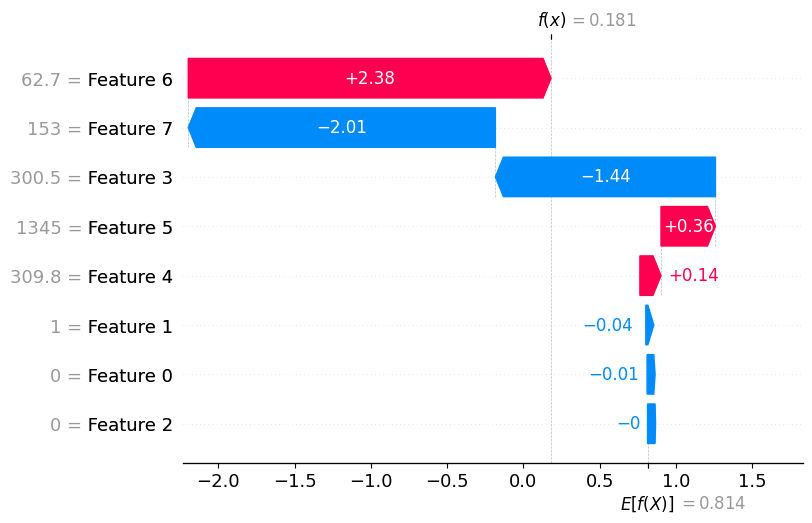

In [85]:
shap.plots.waterfall(
    shap_values[normal_idx],
    max_display=8
)

In [ ]:
# Final model evaluation summary

In [63]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

final_metrics = {
    "Accuracy": accuracy_score(y_test, xgb_test_pred),
    "Precision": precision_score(y_test, xgb_test_pred),
    "Recall": recall_score(y_test, xgb_test_pred),
    "F1 Score": f1_score(y_test, xgb_test_pred),
    "ROC-AUC": roc_auc_score(y_test, xgb_test_prob),
    "PR-AUC": average_precision_score(y_test, xgb_test_prob)
}

final_metrics_df = pd.DataFrame(
    [final_metrics],
    index=["XGBoost"]
).round(4)

final_metrics_df

,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
XGBoost,0.9835,0.7612,0.75,0.7556,0.97,0.8131


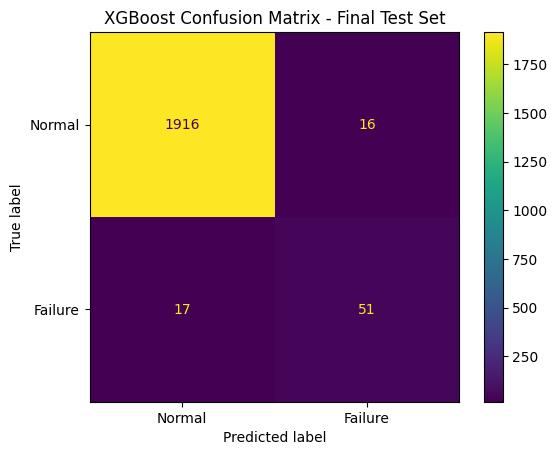

Confusion Matrix:
[[1916   16]
 [  17   51]]


In [64]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, xgb_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Failure"]
)

disp.plot()
plt.title("XGBoost Confusion Matrix - Final Test Set")
plt.show()

print("Confusion Matrix:")
print(cm)

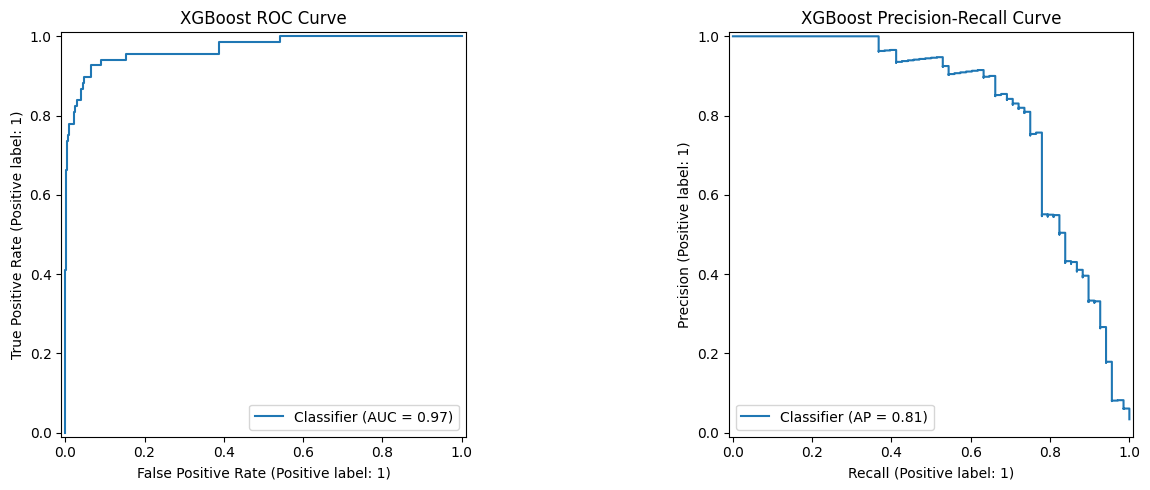

In [65]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

RocCurveDisplay.from_predictions(
    y_test,
    xgb_test_prob,
    ax=axes[0]
)
axes[0].set_title("XGBoost ROC Curve")

PrecisionRecallDisplay.from_predictions(
    y_test,
    xgb_test_prob,
    ax=axes[1]
)
axes[1].set_title("XGBoost Precision-Recall Curve")

plt.tight_layout()
plt.show()

In [ ]:
# Compare all three models

In [66]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "ROC-AUC": [
        0.8995,
        0.9585,
        0.9700
    ],
    "PR-AUC": [
        0.4335,
        0.7745,
        0.8131
    ],
    "Precision": [
        0.67,
        0.91,
        0.7612
    ],
    "Recall": [
        0.15,
        0.46,
        0.75
    ],
    "F1 Score": [
        0.24,
        0.61,
        0.7556
    ]
})

model_comparison

,Model,ROC-AUC,PR-AUC,Precision,Recall,F1 Score
0,Logistic Regression,0.8995,0.4335,0.6700,0.15,0.2400
1,Random Forest,0.9585,0.7745,0.9100,0.46,0.6100
2,XGBoost,0.9700,0.8131,0.7612,0.75,0.7556


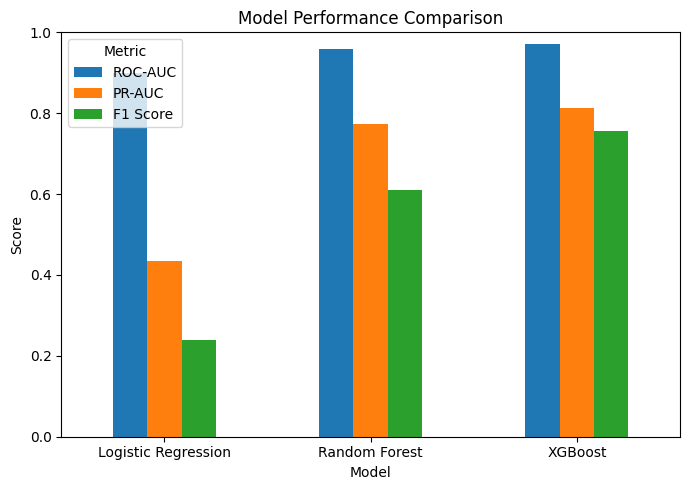

In [67]:
metrics_to_plot = ["ROC-AUC", "PR-AUC", "F1 Score"]

model_comparison.set_index("Model")[metrics_to_plot].plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

In [ ]:
# Save the final model

In [69]:
import joblib

joblib.dump(xgb_final, "xgboost_predictive_maintenance.pkl")
joblib.dump(preprocessor_final, "predictive_maintenance_preprocessor.pkl")

print("Model and preprocessor saved successfully.")

Model and preprocessor saved successfully.


In [ ]:
# Create a sample new machine
Now we will test whether the saved model can take new machine data and produce a failure probability.

In [70]:
new_machine = pd.DataFrame({
    "Type": ["L"],
    "Air temperature [K]": [300.5],
    "Process temperature [K]": [309.8],
    "Rotational speed [rpm]": [1345],
    "Torque [Nm]": [62.7],
    "Tool wear [min]": [153]
})

# Apply the same preprocessing used during training
new_machine_processed = preprocessor_final.transform(new_machine)

# Predict failure probability
new_machine_prob = xgb_final.predict_proba(new_machine_processed)[:, 1][0]

# Apply our validation-selected threshold
new_machine_prediction = int(new_machine_prob >= best_val_threshold)

print("Failure probability:", round(new_machine_prob, 4))
print("Predicted class:", new_machine_prediction)

Failure probability: 0.5452
Predicted class: 0


In [ ]:
# Create a reusable prediction function

In [71]:
def predict_machine_failure(machine_data):
    machine_df = pd.DataFrame([machine_data])

    processed_data = preprocessor_final.transform(machine_df)

    probability = xgb_final.predict_proba(processed_data)[:, 1][0]
    prediction = int(probability >= best_val_threshold)

    return {
        "Failure Probability": round(probability, 4),
        "Prediction": "Failure" if prediction == 1 else "Normal"
    }


# Test the function
result = predict_machine_failure({
    "Type": "L",
    "Air temperature [K]": 300.5,
    "Process temperature [K]": 309.8,
    "Rotational speed [rpm]": 1345,
    "Torque [Nm]": 62.7,
    "Tool wear [min]": 153
})

print(result)

{'Failure Probability': np.float32(0.5452), 'Prediction': 'Normal'}


In [ ]:
# Test the model on a higher-risk machine

In [72]:
high_risk_machine = predict_machine_failure({
    "Type": "L",
    "Air temperature [K]": 300.0,
    "Process temperature [K]": 310.0,
    "Rotational speed [rpm]": 1200,
    "Torque [Nm]": 70.0,
    "Tool wear [min]": 220
})

print(high_risk_machine)

{'Failure Probability': np.float32(0.9959), 'Prediction': 'Failure'}


In [ ]:
# Save the final model comparison table

In [97]:
model_comparison.to_csv(
    "model_comparison.csv",
    index=False
)

print("Model comparison saved successfully.")

Model comparison saved successfully.


In [ ]:
# Predictive Maintenance using Machine Learning

## Project Summary

This project develops a machine failure prediction system using the AI4I 2020 Predictive Maintenance Dataset.

### Objective
Predict whether a machine is likely to experience a failure based on its operating conditions and tool wear.

### Dataset
- 10,000 observations
- 14 original columns
- Target: `Machine failure`
- Failure rate: 3.39%
- No missing values
- No duplicate records

### Machine Learning Approach
Three classification models were evaluated:

1. Logistic Regression
2. Random Forest
3. XGBoost

Because machine failures are relatively rare, model evaluation focused on:
- Precision
- Recall
- F1 Score
- ROC-AUC
- PR-AUC

### Final Model

XGBoost was trained using:
- One-hot encoding for machine Type
- Class imbalance handling using `scale_pos_weight`
- A validation-set-selected classification threshold
- A completely untouched final test set

### Final Test Performance

| Metric | XGBoost |
|---|---:|
| Accuracy | 98.35% |
| Precision | 76.12% |
| Recall | 75.00% |
| F1 Score | 75.56% |
| ROC-AUC | 0.9700 |
| PR-AUC | 0.8131 |

### Explainability

SHAP analysis showed that the model relied primarily on:
- Torque
- Tool wear
- Rotational speed
- Air temperature
- Process temperature

Machine Type had comparatively smaller influence.

SHAP was also used to explain individual failure and normal predictions.

### Deployment Preparation

The trained XGBoost model and preprocessing pipeline were saved using Joblib, and a reusable prediction function was created for new machine 
observations.

In [ ]:
# Prepare the model for deployment

In [74]:
import joblib

deployment_package = {
    "model": xgb_final,
    "preprocessor": preprocessor_final,
    "threshold": best_val_threshold,
    "features": features
}

joblib.dump(
    deployment_package,
    "predictive_maintenance_model.pkl"
)

print("Deployment package saved successfully.")

Deployment package saved successfully.


In [76]:
from flask import Flask, request, jsonify
import joblib
import pandas as pd

app = Flask(__name__)

# Load deployment package
package = joblib.load("predictive_maintenance_model.pkl")

model = package["model"]
preprocessor = package["preprocessor"]
threshold = package["threshold"]

@app.route("/predict", methods=["POST"])
def predict():

    data = request.get_json()

    machine_data = pd.DataFrame([data])

    # Preprocess input
    processed_data = preprocessor.transform(machine_data)

    # Predict probability
    probability = float(
        model.predict_proba(processed_data)[:, 1][0]
    )

    # Apply selected threshold
    prediction = int(probability >= threshold)

    return jsonify({
        "failure_probability": round(probability, 4),
        "prediction": "Failure" if prediction == 1 else "Normal"
    })

if __name__ == "__main__":
    app.run(debug=False, use_reloader=False)

 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
127.0.0.1 - - [22/Sep/2026 14:10:15] "GET / HTTP/1.1" 404 -
127.0.0.1 - - [22/Sep/2026 14:10:15] "GET /favicon.ico HTTP/1.1" 404 -


In [80]:
import requests

test_data = {
    "Type": "L",
    "Air temperature [K]": 300.0,
    "Process temperature [K]": 310.0,
    "Rotational speed [rpm]": 1200,
    "Torque [Nm]": 70.0,
    "Tool wear [min]": 220
}

response = requests.post(
    "http://127.0.0.1:5000/predict",
    json=test_data
)

print(response.json())

In [81]:
%%writefile app.py

from flask import Flask, request, jsonify
import joblib
import pandas as pd

app = Flask(__name__)

package = joblib.load("predictive_maintenance_model.pkl")

model = package["model"]
preprocessor = package["preprocessor"]
threshold = package["threshold"]

@app.route("/predict", methods=["POST"])
def predict():

    data = request.get_json()

    machine_data = pd.DataFrame([data])
    processed_data = preprocessor.transform(machine_data)

    probability = float(
        model.predict_proba(processed_data)[:, 1][0]
    )

    prediction = int(probability >= threshold)

    return jsonify({
        "failure_probability": round(probability, 4),
        "prediction": "Failure" if prediction == 1 else "Normal"
    })


if __name__ == "__main__":
    app.run(debug=False, use_reloader=False)

Writing app.py


In [82]:
import requests

test_data = {
    "Type": "L",
    "Air temperature [K]": 300.0,
    "Process temperature [K]": 310.0,
    "Rotational speed [rpm]": 1200,
    "Torque [Nm]": 70.0,
    "Tool wear [min]": 220
}

response = requests.post(
    "http://127.0.0.1:5000/predict",
    json=test_data
)

print(response.status_code)
print(response.json())

200
{'failure_probability': 0.9959, 'prediction': 'Failure'}


In [83]:
normal_test_data = {
    "Type": "L",
    "Air temperature [K]": 300.5,
    "Process temperature [K]": 309.8,
    "Rotational speed [rpm]": 1345,
    "Torque [Nm]": 62.7,
    "Tool wear [min]": 153
}

response = requests.post(
    "http://127.0.0.1:5000/predict",
    json=normal_test_data
)

print(response.status_code)
print(response.json())

200
{'failure_probability': 0.5452, 'prediction': 'Normal'}


In [84]:
%pip freeze > requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [85]:
with open("requirements.txt", "r") as f:
    print(f.read())

absl-py==2.4.0
aext-assistant @ file:///C:/b/abs_1bfn_ondsd/croot/aext-assistant_1746560154452/work
aext-assistant-server @ file:///C:/b/abs_6f6umrladb/croot/aext-assistant-server_1746552992573/work
aext-core @ file:///C:/b/abs_a0497039ax/croot/aext-core_1746546102863/work
aext-core-server @ file:///C:/b/abs_82tjab_7w4/croot/aext-core-server_1746542360244/work
aext-panels @ file:///C:/b/abs_fde530cwui/croot/aext-panels_1746560097533/work
aext-panels-server @ file:///C:/b/abs_6672ttq6cc/croot/aext-panels-server_1746552976245/work
aext-project-filebrowser-server @ file:///C:/b/abs_79l9wkmqos/croot/aext-project-filebrowser-server_1746563508758/work/backend_lib/project_filebrowser
aext-share-notebook @ file:///C:/b/abs_4dnd8bg_5y/croot/aext-share-notebook_1746556779074/work
aext-share-notebook-server @ file:///C:/b/abs_33583xtbk0/croot/aext-share-notebook-server_1746552715592/work
aext-shared @ file:///C:/b/abs_4fe5it0ngg/croot/aext-shared_1746540522892/work
aext-toolbox @ file:///C:/b/abs

In [86]:
import flask
import pandas
import numpy
import sklearn
import xgboost
import joblib

print("Flask:", flask.__version__)
print("Pandas:", pandas.__version__)
print("NumPy:", numpy.__version__)
print("Scikit-learn:", sklearn.__version__)
print("XGBoost:", xgboost.__version__)
print("Joblib:", joblib.__version__)

Flask: 3.1.0
Pandas: 3.0.1
NumPy: 2.1.0
Scikit-learn: 1.6.1
XGBoost: 3.2.0
Joblib: 1.5.3


C:\Users\Dell\AppData\Local\Temp\ipykernel_9900\2183474634.py:8: DeprecationWarning: The '__version__' attribute is deprecated and will be removed in Flask 3.1. Use feature detection or 'importlib.metadata.version("flask")' instead.
  print("Flask:", flask.__version__)


In [87]:
requirements = """Flask==3.1.0
gunicorn
pandas==3.0.1
numpy==2.1.0
scikit-learn==1.6.1
xgboost==3.2.0
joblib==1.5.3
"""

with open("requirements.txt", "w") as f:
    f.write(requirements)

print("Clean requirements.txt created successfully.")

Clean requirements.txt created successfully.


In [88]:
gitignore = """__pycache__/
*.pyc
.ipynb_checkpoints/
"""

with open(".gitignore", "w") as f:
    f.write(gitignore)

print(".gitignore created successfully.")

.gitignore created successfully.
